In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping
import psutil
import os
import time
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, balanced_accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import tensorflow as tf
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import quantile_transform

In [2]:
import numpy as np
from scipy.stats import ttest_ind
import pandas as pd
# from scipy.stats import chisquare
# from statsmodels.tools.tools import add_constant
# from statsmodels.stats.outliers_influence import variance_inflation_factor
import time
import numpy as np
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.feature_selection import SelectKBest, chi2
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping
import psutil
import os
import matplotlib.pyplot as plt
import pickle
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, balanced_accuracy_score, ConfusionMatrixDisplay
import xlwings as xw

# Load dataset



In [3]:
def Normalization(X_Train):
    value_Train=[]
    key_Train=[]
    for i in(X_Train.columns):
        if X_Train[i].std()==0:
            key_Train.append(i)
            value_Train.append(X_Train[i].max())    
    X_Train=(X_Train-X_Train.min())/(X_Train.max()-X_Train.min())
    for i in (X_Train.columns):
        for j in range(len(key_Train)):
            if key_Train[j]==i:
                if value_Train[j]<=0:
                    X_Train[i]=0
                elif value_Train[j]>0:
                    X_Train[i]=1
    return X_Train
def Quantile_Transform(X_Train):
    qt=quantile_transform(X_Train,  random_state=0, copy=True)
    X_QT = pd.concat([pd.DataFrame(qt)], axis=1)
    return X_QT

def Standardization(X_Train):
    std = (X_Train - X_Train.mean()) / X_Train.std()
    X_STD = pd.concat([pd.DataFrame(std, columns=X_Train.columns)], axis=1)
    return X_STD

In [4]:
# Step 1: Load the dataset
df = pd.read_csv(r'D:\Datasets\Dataset_4L\CICDDoS2019_87F_TRAIN_DATASET_FRONT_SEQUANTIAL_MULTI_CLASS_with_imputation_4L.csv')

#9F
# Features = ['Init_Win_bytes_forward','ACK Flag Count','URG Flag Count','Average Packet Size','Init_Win_bytes_backward',
#             'Max Packet Length','Min Packet Length','min_seg_size_forward','Flow Packets/s',
#             'Label']

#10F
# Features = ['Init_Win_bytes_forward','ACK Flag Count','URG Flag Count','Average Packet Size','Init_Win_bytes_backward',
#             'Max Packet Length','Min Packet Length','min_seg_size_forward','Flow Packets/s','Inbound',
#             'Label']

#11F
# Features = ['Init_Win_bytes_forward','ACK Flag Count','URG Flag Count','Average Packet Size','Init_Win_bytes_backward',
#             'Max Packet Length','Min Packet Length','min_seg_size_forward','Flow Packets/s','Inbound','Flow Duration',
#             'Label']

#12F
# Features = ['Init_Win_bytes_forward','ACK Flag Count','URG Flag Count','Average Packet Size','Init_Win_bytes_backward',
#             'Max Packet Length','Min Packet Length','min_seg_size_forward','Flow Packets/s','Inbound','Flow Duration',
#             'Fwd PSH Flags',
#             'Label']

#13F
# Features = ['Init_Win_bytes_forward','ACK Flag Count','URG Flag Count','Average Packet Size','Init_Win_bytes_backward',
#             'Max Packet Length','Min Packet Length','min_seg_size_forward','Flow Packets/s','Inbound','Flow Duration',
#             'Fwd PSH Flags','Flow IAT Min',
#             'Label']

#14F
# Features = ['Init_Win_bytes_forward','ACK Flag Count','URG Flag Count','Average Packet Size','Init_Win_bytes_backward',
#             'Max Packet Length','Min Packet Length','min_seg_size_forward','Flow Packets/s','Inbound','Flow Duration',
#             'Fwd PSH Flags','Flow IAT Min','Fwd IAT Total',
#             'Label']

#15F
# Features = ['Init_Win_bytes_forward','ACK Flag Count','URG Flag Count','Average Packet Size','Init_Win_bytes_backward',
#             'Max Packet Length','Min Packet Length','min_seg_size_forward','Flow Packets/s','Inbound','Flow Duration',
#             'Fwd PSH Flags','Flow IAT Min','Fwd IAT Total','Fwd IAT Max',
#             'Label']

#16F
# Features = ['Init_Win_bytes_forward','ACK Flag Count','URG Flag Count','Average Packet Size','Init_Win_bytes_backward',
#             'Max Packet Length','Min Packet Length','min_seg_size_forward','Flow Packets/s','Inbound','Flow Duration',
#             'Fwd PSH Flags','Flow IAT Min','Fwd IAT Total','Fwd IAT Max','CWE Flag Count',
#             'Label']

#17F
# Features = ['Init_Win_bytes_forward','ACK Flag Count','URG Flag Count','Average Packet Size','Init_Win_bytes_backward',
#             'Max Packet Length','Min Packet Length','min_seg_size_forward','Flow Packets/s','Inbound','Flow Duration',
#             'Fwd PSH Flags','Flow IAT Min','Fwd IAT Total','Fwd IAT Max','CWE Flag Count','Bwd IAT Std',
#             'Label']

#18F
# Features = ['Init_Win_bytes_forward','ACK Flag Count','URG Flag Count','Average Packet Size','Init_Win_bytes_backward',
#             'Max Packet Length','Min Packet Length','min_seg_size_forward','Flow Packets/s','Inbound','Flow Duration',
#             'Fwd PSH Flags','Flow IAT Min','Fwd IAT Total','Fwd IAT Max','CWE Flag Count','Bwd IAT Std','Idle Mean',
#             'Label']

#19F
# Features = ['Init_Win_bytes_forward','ACK Flag Count','URG Flag Count','Average Packet Size','Init_Win_bytes_backward',
#             'Max Packet Length','Min Packet Length','min_seg_size_forward','Flow Packets/s','Inbound','Flow Duration',
#             'Fwd PSH Flags','Flow IAT Min','Fwd IAT Total','Fwd IAT Max','CWE Flag Count','Bwd IAT Std','Idle Mean',
#             'Active Max',
#             'Label']

#20F
# Features = ['Init_Win_bytes_forward','ACK Flag Count','URG Flag Count','Average Packet Size','Init_Win_bytes_backward',
#             'Max Packet Length','Min Packet Length','min_seg_size_forward','Flow Packets/s','Inbound','Flow Duration',
#             'Fwd PSH Flags','Flow IAT Min','Fwd IAT Total','Fwd IAT Max','CWE Flag Count','Bwd IAT Std','Idle Mean',
#             'Active Max','Fwd Packets/s',
#             'Label']

#21F
# Features = ['Init_Win_bytes_forward','ACK Flag Count','URG Flag Count','Average Packet Size','Init_Win_bytes_backward',
#             'Max Packet Length','Min Packet Length','min_seg_size_forward','Flow Packets/s','Inbound','Flow Duration',
#             'Fwd PSH Flags','Flow IAT Min','Fwd IAT Total','Fwd IAT Max','CWE Flag Count','Bwd IAT Std','Idle Mean',
#             'Active Max','Fwd Packets/s','SYN Flag Count',
#             'Label']

#22F
# Features = ['Init_Win_bytes_forward','ACK Flag Count','URG Flag Count','Average Packet Size','Init_Win_bytes_backward',
#             'Max Packet Length','Min Packet Length','min_seg_size_forward','Flow Packets/s','Inbound','Flow Duration',
#             'Fwd PSH Flags','Flow IAT Min','Fwd IAT Total','Fwd IAT Max','CWE Flag Count','Bwd IAT Std','Idle Mean',
#             'Active Max','Fwd Packets/s','SYN Flag Count','Bwd IAT Min',
#             'Label']

#23F
# Features = ['Init_Win_bytes_forward','ACK Flag Count','URG Flag Count','Average Packet Size','Init_Win_bytes_backward',
#             'Max Packet Length','Min Packet Length','min_seg_size_forward','Flow Packets/s','Inbound','Flow Duration',
#             'Fwd PSH Flags','Flow IAT Min','Fwd IAT Total','Fwd IAT Max','CWE Flag Count','Bwd IAT Std','Idle Mean',
#             'Active Max','Fwd Packets/s','SYN Flag Count','Bwd IAT Min','Fwd IAT Mean',
#             'Label']

#CICIDS2018_19F
# Features = ['Fwd Header Length','Total Fwd Packets','Fwd Packet Length Std','Fwd IAT Min','Flow IAT Min','Flow IAT Mean',
#             'Down/Up Ratio','Fwd Packets/s','Flow Packets/s','act_data_pkt_fwd','Max Packet Length','Packet Length Variance',
#             'Bwd IAT Total','RST Flag Count','Min Packet Length','PSH Flag Count','Fwd IAT Max','Fwd Packet Length Min',
#             'Bwd Packet Length Mean',
#             'Label']

#CICIDS2017_29F
# Features = ['Init_Win_bytes_backward','Bwd Header Length','Bwd IAT Std','Total Backward Packets','Init_Win_bytes_forward',
#             'Packet Length Mean','Bwd Packet Length Mean','Average Packet Size','min_seg_size_forward','Max Packet Length',
#             'Flow Bytes/s','Fwd Packet Length Std','Bwd IAT Mean','Flow IAT Mean','Bwd IAT Total','Flow Duration','Flow IAT Min',
#             'Fwd Header Length','Bwd IAT Min','Down/Up Ratio','Active Max','Fwd Packet Length Min','Fwd IAT Std','Flow IAT Std',
#             'Fwd PSH Flags','Bwd IAT Max','Idle Std','Fwd Packets/s','Packet Length Variance',
#             'Label']

#BASELINE_76F
# Features = ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets','Total Length of Fwd Packets', 
#             'Total Length of Bwd Packets','Fwd Packet Length Max', 'Fwd Packet Length Min','Fwd Packet Length Mean',
#             'Fwd Packet Length Std','Bwd Packet Length Max', 'Bwd Packet Length Min','Bwd Packet Length Mean',
#             'Bwd Packet Length Std', 'Flow Bytes/s','Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
#             'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std','Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 
#             'Bwd IAT Mean','Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags','Bwd PSH Flags', 'Fwd URG Flags', 
#             'Bwd URG Flags', 'Fwd Header Length','Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s','Min Packet Length',
#             'Max Packet Length', 'Packet Length Mean','Packet Length Std', 'Packet Length Variance', 'FIN Flag Count','SYN Flag Count', 
#             'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count','URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 
#             'Down/Up Ratio','Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size','Fwd Avg Bytes/Bulk', 
#             'Fwd Avg Packets/Bulk','Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk','Bwd Avg Bulk Rate', 
#             'Subflow Fwd Packets', 'Subflow Fwd Bytes','Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Init_Win_bytes_forward',
#             'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward','Active Mean', 'Active Std', 'Active Max', 
#             'Active Min', 'Idle Mean','Idle Std', 'Idle Max', 'Idle Min',
#             'Label']

# PAPER_16_22F_MALDAVIFAR@2019
# Features= ['Fwd Packet Length Min','Packet Length Mean','Min Packet Length','Average Packet Size','Max Packet Length',
#           'Fwd Packet Length Mean','Avg Fwd Segment Size', 'Total Length of Fwd Packets','Subflow Fwd Bytes',
#           'Fwd Packet Length Max', 'Flow Bytes/s','Fwd Header Length','Fwd Header Length.1','Flow Duration',
#           'Flow IAT Mean','Fwd Packets/s','Flow Packets/s','Flow IAT Max','Fwd IAT Total', 'Fwd IAT Max','Fwd IAT Mean',
#           'Protocol',
#           'Label']

# PAPER_17_10F_G.C. Amaizu@2021
# Features = ['Fwd Packet Length Max','Flow Packets/s','Average Packet Size', 'Subflow Fwd Bytes','Avg Fwd Segment Size', 
#            'Flow IAT Std','Min Packet Length', 'Total Fwd Packets','Packet Length Variance','Protocol',
#            'Label']

# PAPER_18_25F_J_HALLEDY@
# Features = ['Flow Duration', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean',
#             'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total',
#             'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
#             'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
#             'Bwd IAT Min', 'Active Mean', 'Active Std', 'Active Max', 'Active Min',
#             'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min', 
#             'Label']

# PAPER_19_20F_H.A.Alamri@
# Features = ['Protocol','Average Packet Size','Min Packet Length','Fwd Packet Length Mean','Avg Fwd Segment Size',
#             'Fwd Packet Length Min','Packet Length Mean','Fwd Packet Length Max','ACK Flag Count', 'Flow Bytes/s', 
#             'Source Port', 'Max Packet Length','Fwd Packets/s','Flow Packets/s','Subflow Fwd Bytes', 
#             'Total Length of Fwd Packets', 'Flow Duration', 'Fwd IAT Total','Source IP', 'Destination IP', 
#             'Label']

#PAPER_20_14F_A. A. Alashhab@
# Features = ['Flow Duration','Init_Win_bytes_forward', 'Average Packet Size','RST Flag Count','SYN Flag Count',
#             'FIN Flag Count','Packet Length Variance','Total Length of Fwd Packets', 'Total Length of Bwd Packets',
#             'Total Backward Packets','Total Fwd Packets', 'Flow Bytes/s','Flow Packets/s','Init_Win_bytes_backward',
#             'Label']

# PAPER_21_43F_NAJAR@:
# Features = ['Total Fwd Packets', 'Total Backward Packets','Total Length of Fwd Packets', 'Fwd Packet Length Max', 
#             'Fwd Packet Length Min','Fwd Packet Length Mean', 'Fwd Packet Length Std','Bwd Packet Length Mean', 
#             'Flow Bytes/s','Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max','Flow IAT Min',  
#             'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
#             'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length','Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
#             'Max Packet Length', 'Packet Length Mean','Packet Length Std', 'Packet Length Variance', 'Average Packet Size',
#             'Avg Fwd Segment Size', 'Init_Win_bytes_forward','Init_Win_bytes_backward', 'act_data_pkt_fwd', 'Active Mean',
#             'Active Std', 'Active Max', 'Active Min', 'Idle Mean','Idle Std', 'Idle Max', 'Idle Min', 
#             'Label' ]

# PAPER_22_59F_Manthena R@
# Features = ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
#        'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
#        'Fwd Packet Length Max', 'Fwd Packet Length Min',
#        'Fwd Packet Length Mean', 'Fwd Packet Length Std',
#        'Bwd Packet Length Max', 'Bwd Packet Length Min',
#        'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
#        'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
#        'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
#        'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
#        'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
#        'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s',
#        'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length',
#        'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
#        'SYN Flag Count', 'RST Flag Count', 'ACK Flag Count', 'URG Flag Count',
#        'CWE Flag Count', 'Down/Up Ratio', 'Average Packet Size',
#        'Avg Fwd Segment Size', 'Avg Bwd Segment Size',
#        'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd',
#        'min_seg_size_forward', 'Active Mean', 'Active Std', 'Active Max',
#        'Active Min', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min', 
#             'Label']

# PAPER_23_5F_RAJU@2022
# Features = ['Init_Win_bytes_forward','Min Packet Length ','Inbound ','Protocol ','ACK Flag Count']
# PAPER_23_6F_RAJU@2022
# Features = ['Total Backward Packets','Fwd Packet Length Min','URG Flag Count','Down/Up Ratio','Active Mean','Inbound','Label']

#PAPER_24*_CIl et.al @69 FEATURES
# Features = ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
#        'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
#        'Fwd Packet Length Max', 'Fwd Packet Length Min',
#        'Fwd Packet Length Mean', 'Fwd Packet Length Std',
#        'Bwd Packet Length Max', 'Bwd Packet Length Min',
#        'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
#        'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
#        'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
#        'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
#        'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
#         'Fwd Header Length',
#        'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
#        'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
#        'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
#        'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count',
#        'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ratio',
#        'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size',
#         'Subflow Fwd Packets', 'Subflow Fwd Bytes',
#        'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Init_Win_bytes_forward',
#        'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward',
#        'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Mean',
#        'Idle Std', 'Idle Max', 'Idle Min', 'Inbound', 
#             'Label']

#PAPER_25*_Wei, Y. et.al @20 FEATURES

# Features = ['Min Packet Length','Fwd Packet Length Mean','Fwd Packet Length Min','Average Packet Size',
#             'Fwd Packet Length Max','Max Packet Length','Protocol','Flow IAT Mean','Init_Win_bytes_forward',
#             'URG Flag Count','Flow Duration','Flow IAT Std','Flow IAT Min','Fwd Packets/s','Total Length of Fwd Packets',
#             'Fwd IAT Total','Total Fwd Packets','Total Backward Packets','act_data_pkt_fwd','Fwd IAT Mean',
#             'Label']

#27F_T2_SHAP_product_Median
# Features = ['Bwd IAT Max','Bwd IAT Mean','Idle Max','Idle Mean','Flow IAT Std','Bwd IAT Std','Idle Min','Flow Duration',
#             'Flow IAT Max','Fwd IAT Mean','Flow IAT Mean','Fwd IAT Std','Idle Std','Fwd IAT Total','Active Min','Active Max',
#             'Fwd IAT Max','Active Mean','Bwd Packets/s','Total Length of Bwd Packets','Bwd Header Length','Init_Win_bytes_backward',
#             'Flow Packets/s','Fwd Packets/s','Fwd IAT Min','Flow IAT Min','Bwd Packet Length Max', 
#             'Label']

#26F_robust_z_score=3
# Features = ['Bwd IAT Max','Bwd IAT Mean','Idle Max','Idle Mean','Flow IAT Std','Bwd IAT Std','Idle Min','Flow Duration',
#             'Flow IAT Max','Fwd IAT Mean','Flow IAT Mean','Fwd IAT Std','Idle Std','Fwd IAT Total','Active Min','Active Max',
#             'Fwd IAT Max','Active Mean','Bwd Packets/s','Total Length of Bwd Packets','Bwd Header Length','Init_Win_bytes_backward',
#             'Flow Packets/s','Fwd Packets/s','Fwd IAT Min','Flow IAT Min',
#             'Label']

#18F_ALL_z_score>0
# Features = ['Bwd Header Length','Bwd IAT Max','Bwd IAT Min','Bwd IAT Std','Bwd Packet Length Max','Bwd Packets/s','Down/Up Ratio',
#             'Flow Packets/s','Fwd Packet Length Min','Idle Max','Idle Mean','Idle Min','Inbound','Init_Win_bytes_forward',
#             'Min Packet Length','Total Backward Packets','Total Length of Fwd Packets','URG Flag Count',
#             'Label']

#1F_ALL_z_score_Intersction
# Features = ['Bwd IAT Max',
#             'Label']

#9F_ALL_z_score>1
# Features = ['Bwd IAT Max','Bwd Packets/s','Fwd Packet Length Min',
#             'Idle Max','Idle Mean','Idle Min','Inbound',
#             'Total Backward Packets','URG Flag Count',
#             'Label']

#7F_ALL_z_score>2
# Features = ['Bwd IAT Max','Bwd Packets/s','Idle Max','Idle Mean','Idle Min','Inbound','URG Flag Count',
#             'Label']

#4F_ALL_z_score>3
# Features = ['Bwd IAT Max','Idle Max','Idle Mean','Inbound',
#             'Label']

#14F_SHAP_z_score>0
# Features = ['Bwd Header Length','Bwd IAT Max','Bwd IAT Min','Bwd Packet Length Max','Bwd Packets/s','Down/Up Ratio','Flow Packets/s',
#             'Fwd Packet Length Min','Inbound','Init_Win_bytes_forward','Min Packet Length','Total Backward Packets',
#             'Total Length of Fwd Packets','URG Flag Count',
#             'Label']

#6F_SHAP_z_score>1
Features = ['Inbound','URG Flag Count','Bwd Packets/s',
            'Fwd Packet Length Min','Bwd IAT Max','Total Backward Packets',
            'Label']

#3F_SHAP_z_score>2
# Features = ['Bwd Packets/s','Inbound','URG Flag Count',
#             'Label']

#1F_SHAP_z_score>3
# Features = ['Inbound',
#             'Label']

#5F_T2_z_score>0
# Features = ['Bwd IAT Max','Bwd IAT Std','Idle Max','Idle Mean','Idle Min',
#             'Label']

#4F_T2_z_score>2
# Features = ['Bwd IAT Max','Idle Max','Idle Mean','Idle Min',
#             'Label']

#3F_T2_z_score>3
# Features = ['Bwd IAT Max','Idle Max','Idle Mean',
#             'Label']


df=df[Features]
df['Label']= [0 if x == 'BENIGN' else 1 for x in df['Label']]




C:\Users\asus\AppData\Local\Temp\ipykernel_9936\3820938761.py:2: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'D:\Datasets\Dataset_4L\CICDDoS2019_87F_TRAIN_DATASET_FRONT_SEQUANTIAL_MULTI_CLASS_with_imputation_4L.csv')


In [5]:
len(Features)-1

6

In [6]:
def ROC_AUC(y_test, y_pred,title):  
    fpr, tpr, thresholds = roc_curve(y_test, y_pred) 
    roc_auc = auc(fpr, tpr)
    #File=M+".png"
    #P=os.path.join(P_T,File)
    # Plot the ROC curve
    fig=plt.figure()  
    plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([-0.03, 1.05])
    plt.ylim([-0.03, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for '+ title)
    plt.legend()
   # plt.savefig(title+'.png')
    return fig

In [7]:
import xlwings as xw
def Evaluation_Metrics(y_test, y_pred_binary,Dataset_Name,Output_path):
    directory = os.path.join(Output_path, Dataset_Name)
    if not os.path.exists(directory):
        os.makedirs(directory)
    images_dir = os.path.join(directory, "images")
    os.makedirs(images_dir, exist_ok=True)
    sheet=wb.sheets.add(Dataset_Name) 
    Result=pd.DataFrame()
    Classifier=[]
    ACCURACY=[]
    Balanced_Accuracy=[]
    SN=[]
    SP=[]
    Pre=[]
    FS=[]
    Test= confusion_matrix(y_test, y_pred_binary)
    TP=Test[1][1]
    TN=Test[0][0]
    FP=Test[0][1]
    FN=Test[1][0]
    Sensitivity=TP/(TP+FN)
    Specificity=TN/(TN+FP)
    Precision=TP/(TP+FP)
    Accuracy=(TP+TN)/(TP+TN+FP+FN)
    F1_SCORE=2*((Precision*Sensitivity)/(Precision+Sensitivity))
    BA=(Sensitivity+Specificity)/2
    print("Accuracy :", Accuracy)
    print("Sensitivity :", Sensitivity)
    print("Specificity :", Specificity)
    print("Precision :", Precision)
    print("F1_SCORE :", F1_SCORE)
    print("Balance Accuracy :", BA)
    #Classifier.append(file_name)
    ACCURACY.append(Accuracy)
    Balanced_Accuracy.append(BA)
    SN.append(Sensitivity)
    SP.append(Specificity)
    Pre.append(Precision)
    FS.append(F1_SCORE)
    #Result['Classifier']=Classifier
    Result['ACCURACY']=ACCURACY
    Result['Sensitivity']=SN
    Result['Specificity']=SP
    Result['Precision']=Pre
    Result['F1_SCORE']=FS
    Result['Balanced_Accuracy']=Balanced_Accuracy
    #     Result['Train_Time/s']=Train_Time
    #     Result['Test_Time/s']=Test_Time
    #     Result['Memory_Utilized']=Memory
    sheet.range('A22').value='Test_results'
    sheet.range('A24').value=Result
    #sheet.range('A18').value=Features
    wb.save()
    label_mapping = {0: 'BENIGN', 1: 'DDoS'}
    y_true_labels=y_test.tolist()
    y_pred_labels = y_pred_binary.flatten()
    y_true_labels = [label_mapping[val] for val in y_true_labels]
    y_pred_labels = [label_mapping[val] for val in y_pred_labels]
    label=['BENIGN','DDoS']
    cm = confusion_matrix(y_true_labels, y_pred_labels,labels=label)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=label)
    #disp.plot(cmap='Blues')
    disp.plot(cmap='Blues', values_format='.0f',text_kw={'fontsize': 14})
    plt.xlabel('')
    plt.ylabel('')
    plt.savefig(os.path.join(images_dir,str(len(X_test.columns))+'Test_Confusion_Matrix.png'))
    current_directory = os.getcwd()
    #Im_Path=current_directory+'/'+str(len(X_test.columns))+'Test_Confusion_Matrix.png'
    Im_Path=os.path.join(images_dir, str(len(X_test.columns))+'Test_Confusion_Matrix.png')
    sheet.pictures.add(Im_Path, 
               left=sheet.range('B30').left, 
               top=sheet.range('B30').top, 
               width=400,  # Specify width (optional)
               height=300)
    roc_fig=ROC_AUC(y_test, y_pred_binary, 'MLP')
    Im_Path=os.path.join(images_dir,f"Test_MLP_{len(X_test.columns)}_ROC.png")
    roc_fig.savefig(Im_Path)
    sheet.pictures.add(Im_Path, 
           left=sheet.range('L30').left, 
           top=sheet.range('L30').top, 
           width=400,  # Specify width (optional)
           height=300)
    wb.save()
#wb.close()

In [8]:
batch_size=int(input('enter the batch size: '))
type(batch_size)
# Step 6: Build the CNN model
# Define the model architecture
model = Sequential()

# Input layer (implicitly defined by input shape) + 1st hidden layer

input_dim = len(Features)-1
model.add(Dense(1024, input_dim=input_dim,  activation='relu'))

# Dropout after 1st hidden layer
model.add(Dropout(0.3))
model.add(BatchNormalization())




model.add(Dense(512,  activation='relu'))

# Dropout after 1st hidden layer
model.add(Dropout(0.3))
model.add(BatchNormalization())



model.add(Dense(256,  activation='relu'))

# Dropout after 1st hidden layer
model.add(Dropout(0.3))
model.add(BatchNormalization())


model.add(Dense(128, activation='relu'))

# Dropout after 1st hidden layer
model.add(Dropout(0.3))
model.add(BatchNormalization())
# 2nd hidden layer

# 3rd hidden layer
model.add(Dense(64, activation='relu'))

# Dropout after 1st hidden layer
model.add(Dropout(0.3))
model.add(BatchNormalization())

# Output layer for binary classification
model.add(Dense(1, activation='sigmoid'))

# Compile the model with Adam optimizer, binary cross-entropy loss, and metrics
model.compile(optimizer=Adam(learning_rate=0.001, beta_1=0.999), 
              loss=BinaryCrossentropy(), 
              metrics=['accuracy'])

# Print the model summary
model.summary()

enter the batch size:  1024


C:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1024)                │           7,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1024)                │           4,096 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 712,449 (2.72 MB)

 Trainable params: 708,481 (2.70 MB)

 Non-trainable params: 3,968 (15.50 KB)

In [9]:
# base_path = r'D:\Datasets\Dataset_4L\Testing\Results\BINARY\HTS_SHAPE_23F_EXP\16F_Test'
# base_path = r'D:\Datasets\Dataset_4L\Testing\Results\BINARY\HTS_SHAPE_23F_EXP\PAPER_25_Wei_Y'
base_path = r'D:\Datasets\Dataset_4L\Testing\Results\BINARY\SHAP_RHTS\SHAP_RHTS_z_score\SHAP_z_score_1_6F'

def create_directory(path):
    # Create the directory if it doesn't exist
    if not os.path.exists(path):
        os.makedirs(path)
        print(f"Directory created at: {path}")
    else:
        print(f"Directory already exists at: {path}")
    return path 

# Normalization_Path = os.path.join(base_path, 'Normalization\D1_RESULTS\models')
# Quantile_Path = os.path.join(base_path, 'Quantile\D1_RESULTS\models')
# Standardization_Path = os.path.join(base_path, 'Standardization\D1_RESULTS\models')

Min_Max_Normalization

Directory created at: D:\Datasets\Dataset_4L\Testing\Results\BINARY\SHAP_RHTS\SHAP_RHTS_z_score\SHAP_z_score_1_6F\Min_Max_Normalization


C:\Users\asus\AppData\Local\Temp\ipykernel_9936\824553653.py:12: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=False.
  Validation_set= pd.read_csv(r"D:\Datasets\Dataset_4L\Testing\CICDDoS2019_87F_TESTING_DATASET_BACK_SEQUANTIAL_MULTI_Replace.csv")


Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 44ms/step - accuracy: 0.9609 - loss: 0.1555 - val_accuracy: 0.7438 - val_loss: 0.4576
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.9897 - loss: 0.0420 - val_accuracy: 0.9935 - val_loss: 0.0518
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.9903 - loss: 0.0380 - val_accuracy: 0.9922 - val_loss: 0.0415
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.9904 - loss: 0.0363 - val_accuracy: 0.9881 - val_loss: 0.0626
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 67ms/step - accuracy: 0.9917 - loss: 0.0335 - val_accuracy: 0.9935 - val_loss: 0.0499
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 64ms/step - accuracy: 0.9916 - loss: 0.0322 - val_accuracy: 0.9922 - val_loss: 0.0637
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.9918 - loss: 0.0312 - val_accuracy: 0.9887 - val_loss: 0.0685
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 67ms/step - accuracy: 0.9917 - loss: 0.0313 - 

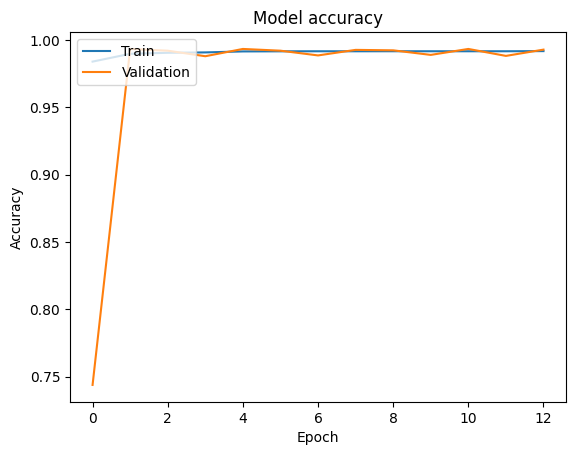

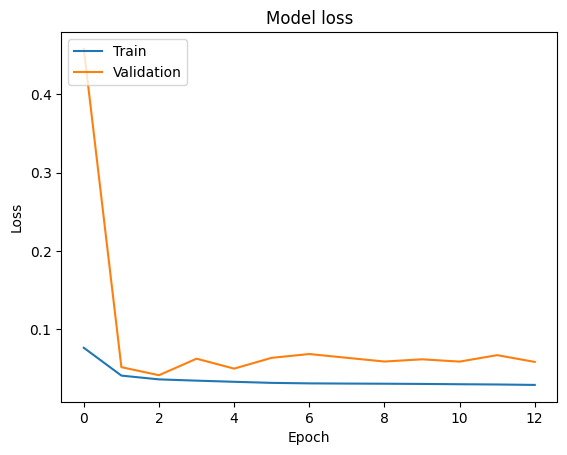

C:\Users\asus\AppData\Local\Temp\ipykernel_9936\824553653.py:75: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=False.
  df1= pd.read_csv(r"D:\Datasets\Dataset_4L\Testing\CICDDoS2019_87F_TESTING_DATASET_FRONT_SEQUANTIAL_MULTI_Replace.csv")


(112611, 7)
Label
0    56306
1    56305
Name: count, dtype: int64
3520/3520 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9911 - loss: 0.0553
Test Loss: 0.042373571544885635
Test Accuracy: 0.9924341440200806
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
Test_Time(Sec) : 2.6933274269104004
Predictions (binary): [[0]
 [0]
 [0]
 ...
 [1]
 [1]
 [1]]
Manual Accuracy: 0.9924341316567653
Sensitivity : 0.9941923452624101
Specificity : 0.9906759492771641
Precision : 0.9907084579579846
Accuracy : 0.9924341316567653
F1_SCORE : 0.9924473441599886
Balance Accuracy : 0.9924341472697871


C:\Users\asus\AppData\Local\Temp\ipykernel_9936\824553653.py:145: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=False.
  df3= pd.read_csv(r'D:\Datasets\Dataset_4L\Testing\CICDDoS2019_87F_TESTING_DATASET_RANDOM_1_MULTI_Replace.csv')


(112611, 7)
Label
0    56306
1    56305
Name: count, dtype: int64
3520/3520 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9914 - loss: 0.0541
Test Loss: 0.03804859519004822
Test Accuracy: 0.9935175180435181
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
Test_Time(Sec) : 1.9946789741516113
Predictions (binary): [[0]
 [0]
 [0]
 ...
 [1]
 [1]
 [1]]
Manual Accuracy: 0.9935175071707026
Sensitivity : 0.9963591155314804
Specificity : 0.9906759492771641
Precision : 0.990728476821192
Accuracy : 0.9935175071707026
F1_SCORE : 0.9935358186487204
Balance Accuracy : 0.9935175324043222


C:\Users\asus\AppData\Local\Temp\ipykernel_9936\824553653.py:178: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=False.
  df4= pd.read_csv(r'D:\Datasets\Dataset_4L\Testing\CICDDoS2019_87F_TESTING_DATASET_RANDOM_2_MULTI_Replace.csv')


(112611, 7)
Label
0    56306
1    56305
Name: count, dtype: int64
3520/3520 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9914 - loss: 0.0540
Test Loss: 0.037826161831617355
Test Accuracy: 0.9935974478721619
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Test_Time(Sec) : 1.204693078994751
Predictions (binary): [[0]
 [0]
 [0]
 ...
 [1]
 [1]
 [1]]
Manual Accuracy: 0.9935974283151735
Sensitivity : 0.9965189592398543
Specificity : 0.9906759492771641
Precision : 0.9907299502065897
Accuracy : 0.9935974283151735
F1_SCORE : 0.9936160228087728
Balance Accuracy : 0.9935974542585092


C:\Users\asus\AppData\Local\Temp\ipykernel_9936\824553653.py:212: DtypeWarning: Columns (84) have mixed types. Specify dtype option on import or set low_memory=False.
  validation= pd.read_csv(r'D:\Datasets\Dataset_4L\CICDDoS2019_87F_VALIDATION_BACK_SEQUANTIAL_MULTI_CLASS_1L.csv')


(112612, 7)
Label
0    56425
1    56187
Name: count, dtype: int64
3520/3520 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9913 - loss: 0.0500
Test Loss: 0.036187201738357544
Test Accuracy: 0.9933488368988037
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Test_Time(Sec) : 1.2069923877716064
Predictions (binary): [[0]
 [0]
 [0]
 ...
 [1]
 [1]
 [1]]
Manual Accuracy: 0.9933488438177104
Sensitivity : 0.9946606866356986
Specificity : 0.9920425343376164
Precision : 0.9920299630786709
Accuracy : 0.9933488438177104
F1_SCORE : 0.9933435830896795
Balance Accuracy : 0.9933516104866575


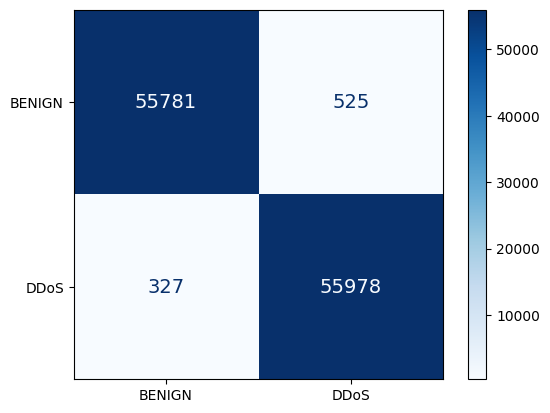

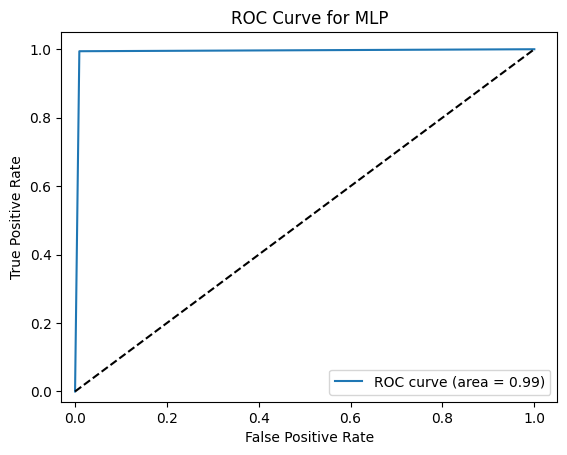

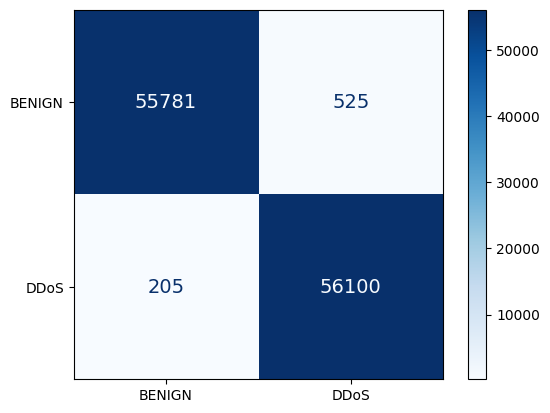

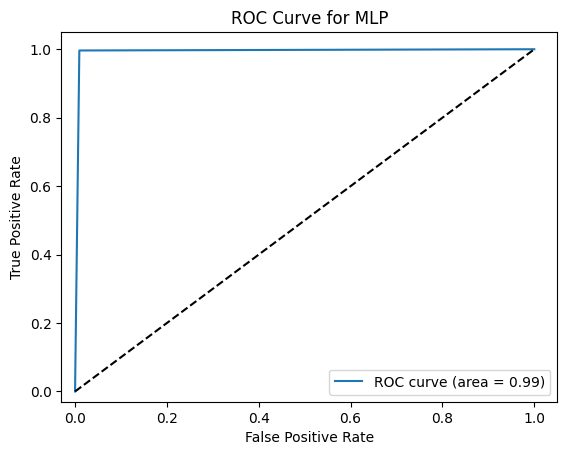

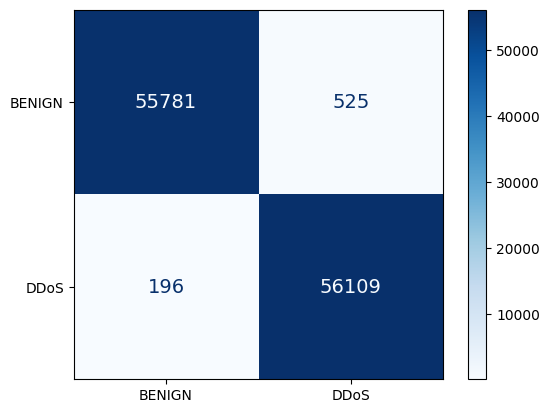

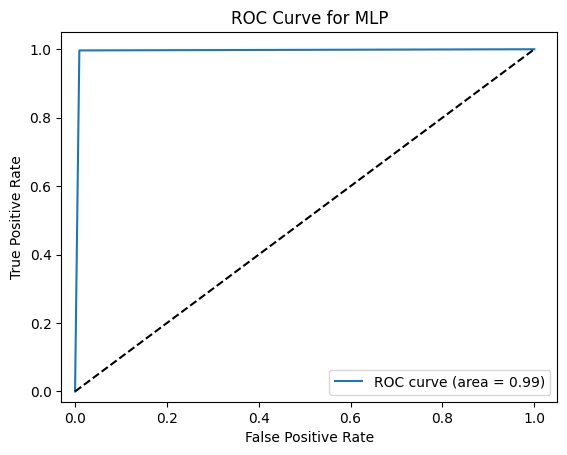

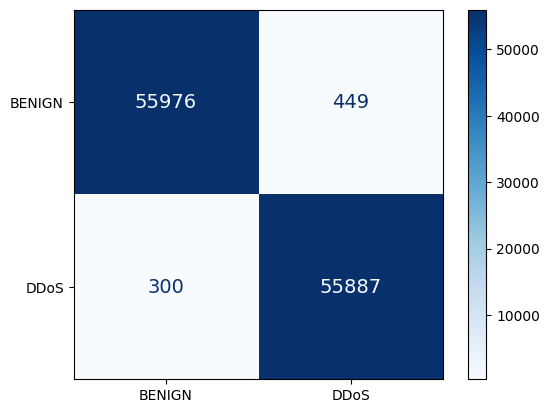

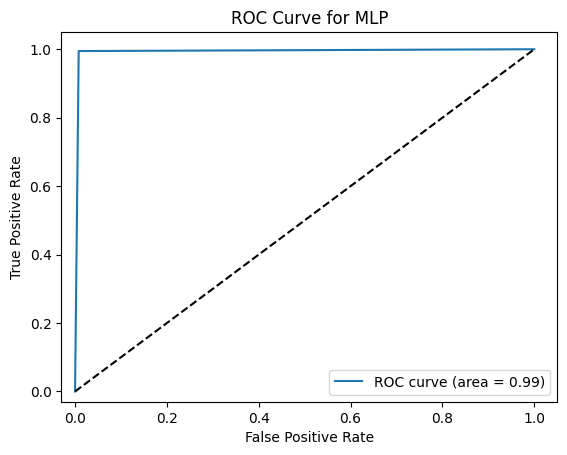

In [10]:

normalization_path = os.path.join(base_path, "Min_Max_Normalization")
Path = create_directory(normalization_path)
#print(Min_Max_Normalization_Path)

current_dir_name = os.path.basename(Path)

X = df.iloc[:,:-1]  # Drop the label column to get features
y_train = df.iloc[:,-1:]
X_train=Normalization(X)

# Validation_set= pd.read_csv(r'D:\Datasets\Dataset_4L\CICDDoS2019_87F_VALIDATION_BACK_SEQUANTIAL_MULTI_CLASS_1L.csv')
Validation_set= pd.read_csv(r"D:\Datasets\Dataset_4L\Testing\CICDDoS2019_87F_TESTING_DATASET_BACK_SEQUANTIAL_MULTI_Replace.csv")
Validation_set=Validation_set[Features]
Validation_set['Label']=[0 if x == 'BENIGN' else 1 for x in Validation_set['Label']]
X_val=Validation_set.iloc[:,:-1]
X_val=Normalization(X_val)
y_val=Validation_set['Label']



#df= pd.read_csv(r'C:\Users\Student\RAGHU\CICDDoS2019_FROM_JULY_2024\4L_DATASET\4L_INBOUND_DATASET\Original\REPLACE_NEGATIVE\CICDDoS2019_87F_TRAIN_DATASET_FRONT_SEQUANTIAL_MULTI_CLASS_with_imputation_4L.csv')

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
before_memory = psutil.Process().memory_info().rss
start=time.time()
# Fit the model with early stopping callback
history = model.fit(X_train, y_train,
                    batch_size=batch_size,
                    epochs=50,
                    validation_data=(X_val, y_val),
                    callbacks=[early_stopping])
after_memory = psutil.Process().memory_info().rss
memory_used=after_memory-before_memory
end=time.time()
print("Memory_Used (MB):",memory_used/(1024*1024))
print("Train_Time(Sec) :", (end-start))

test_loss, test_accuracy = model.evaluate(X_val, y_val)
print(f'Validation Loss: {test_loss}')
print(f'Validation Accuracy: {test_accuracy}')
# Step 9: Evaluate the model on test data
model_filename = current_dir_name+"_"+"4L_MLP_model_WVC_15F_RANDOM_1_MIN_MAX_5_LAYERS_BATCH_1024.sav"
model_save_path = os.path.join(Path, model_filename)
pickle.dump(model, open(model_save_path,'wb'))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.savefig(os.path.join(Path, 'MLP_4L_15F_5_layers_validation_accuracy.png'))
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig(os.path.join(Path,'MLP_4L_15F_5_layers_validation_Loss.png'))
plt.show()





wb = xw.Book()
# Assuming you have trained the model and X_train, y_train are your training data
# X_test and y_test are your test data
# Also assuming normalization was applied to X_train, so apply the same transformation to X_test

df1= pd.read_csv(r"D:\Datasets\Dataset_4L\Testing\CICDDoS2019_87F_TESTING_DATASET_FRONT_SEQUANTIAL_MULTI_Replace.csv")
df1=df1[Features]
df1['Label']=[0 if x == 'BENIGN' else 1 for x in df1['Label']]
print(df1.shape)
print(df1['Label'].value_counts())


X_test = df1.iloc[:,:-1]
y_test=df1['Label']
# Preprocess X_test if needed (e.g., normalization, scaling)
X_test = Normalization(X_test)  # Make sure the normalization is consistent with the training data

# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# Make predictions on test data
start=time.time()
y_pred = model.predict(X_test, batch_size=batch_size)
end=time.time()
print("Test_Time(Sec) :", (end-start))
# Convert predictions to binary (0 or 1) using a threshold of 0.5
y_pred_binary = (y_pred > 0.5).astype(int)

# Print first 10 predictions
print(f"Predictions (binary): {y_pred_binary[:112611]}")

# Calculate accuracy manually (optional)
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Manual Accuracy: {accuracy}")
Evaluation_Metrics(y_test, y_pred_binary,"D1_Dataset",Path)


# df2= pd.read_csv(r'D:\Datasets\Dataset_4L\Testing\CICDDoS2019_87F_TESTING_DATASET_BACK_SEQUANTIAL_MULTI_Replace.csv')
# df2=df2[Features]
# df2['Label']=[0 if x == 'BENIGN' else 1 for x in df2['Label']]
# print(df2.shape)
# print(df2['Label'].value_counts())

# X_test = df2.iloc[:,:-1]
# y_test=df2['Label']
# # Preprocess X_test if needed (e.g., normalization, scaling)
# X_test = Normalization(X_test)  # Make sure the normalization is consistent with the training data

# # Evaluate the model on test data
# # test_loss, test_accuracy = model.evaluate(X_test, y_test)
# # print(f"Test Loss: {test_loss}")
# # print(f"Test Accuracy: {test_accuracy}")

# # Make predictions on test data
# start=time.time()
# y_pred = model.predict(X_test, batch_size=batch_size)
# end=time.time()
# print("Test_Time(Sec) :", (end-start))
# # Convert predictions to binary (0 or 1) using a threshold of 0.5
# y_pred_binary = (y_pred > 0.5).astype(int)

# # Print first 10 predictions
# print(f"Predictions (binary): {y_pred_binary[:112611]}")

# # Calculate accuracy manually (optional)
# accuracy = accuracy_score(y_test, y_pred_binary)
# print(f"Manual Accuracy: {accuracy}")
# #wb = xw.Book()
# Evaluation_Metrics(y_test, y_pred_binary,"D2_Dataset",Path)




df3= pd.read_csv(r'D:\Datasets\Dataset_4L\Testing\CICDDoS2019_87F_TESTING_DATASET_RANDOM_1_MULTI_Replace.csv')
df3=df3[Features]
df3['Label']=[0 if x == 'BENIGN' else 1 for x in df3['Label']]
print(df3.shape)
print(df3['Label'].value_counts())
X_test = df3.iloc[:,:-1]
y_test=df3['Label']
# Preprocess X_test if needed (e.g., normalization, scaling)
X_test = Normalization(X_test)  # Make sure the normalization is consistent with the training data

# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# Make predictions on test data
start=time.time()
y_pred = model.predict(X_test, batch_size=batch_size)
end=time.time()
print("Test_Time(Sec) :", (end-start))
# Convert predictions to binary (0 or 1) using a threshold of 0.5
y_pred_binary = (y_pred > 0.5).astype(int)

# Print first 10 predictions
print(f"Predictions (binary): {y_pred_binary[:112611]}")

# Calculate accuracy manually (optional)
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Manual Accuracy: {accuracy}")
Evaluation_Metrics(y_test, y_pred_binary,"D3_Dataset",Path)



df4= pd.read_csv(r'D:\Datasets\Dataset_4L\Testing\CICDDoS2019_87F_TESTING_DATASET_RANDOM_2_MULTI_Replace.csv')
df4=df4[Features]
df4['Label']=[0 if x == 'BENIGN' else 1 for x in df4['Label']]
print(df4.shape)
print(df4['Label'].value_counts())
X_test = df4.iloc[:,:-1]
y_test=df4['Label']
# Preprocess X_test if needed (e.g., normalization, scaling)
X_test = Normalization(X_test)  # Make sure the normalization is consistent with the training data

# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# Make predictions on test data
start=time.time()
y_pred = model.predict(X_test, batch_size=batch_size)
end=time.time()
print("Test_Time(Sec) :", (end-start))
# Convert predictions to binary (0 or 1) using a threshold of 0.5
y_pred_binary = (y_pred > 0.5).astype(int)

# Print first 10 predictions
print(f"Predictions (binary): {y_pred_binary[:112611]}")

# Calculate accuracy manually (optional)
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Manual Accuracy: {accuracy}")
Evaluation_Metrics(y_test, y_pred_binary,"D4_Dataset",Path)




validation= pd.read_csv(r'D:\Datasets\Dataset_4L\CICDDoS2019_87F_VALIDATION_BACK_SEQUANTIAL_MULTI_CLASS_1L.csv')
validation=validation[Features]
validation['Label']=[0 if x == 'BENIGN' else 1 for x in validation['Label']]
print(validation.shape)
print(validation['Label'].value_counts())
X_test = validation.iloc[:,:-1]
y_test=validation['Label']
# Preprocess X_test if needed (e.g., normalization, scaling)
X_test = Normalization(X_test)  # Make sure the normalization is consistent with the training data

# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# Make predictions on test data
start=time.time()
y_pred = model.predict(X_test, batch_size=batch_size)
end=time.time()
print("Test_Time(Sec) :", (end-start))
# Convert predictions to binary (0 or 1) using a threshold of 0.5
y_pred_binary = (y_pred > 0.5).astype(int)

# Print first 10 predictions
print(f"Predictions (binary): {y_pred_binary[:112611]}")

# Calculate accuracy manually (optional)
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Manual Accuracy: {accuracy}")
Evaluation_Metrics(y_test, y_pred_binary,"Validation_Dataset", Path)



excel_filename = "Min_Max_WVC_15F_RANDOM_1_Results.xlsx"
excel_save_path = os.path.join(Path, excel_filename)
wb.save(excel_save_path)
wb.close()

Directory created at: D:\Datasets\Dataset_4L\Testing\Results\BINARY\SHAP_RHTS\SHAP_RHTS_z_score\SHAP_z_score_1_6F\Quantile_Normalization


C:\Users\asus\AppData\Local\Temp\ipykernel_9936\1826519622.py:12: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=False.
  Validation_set= pd.read_csv(r"D:\Datasets\Dataset_4L\Testing\CICDDoS2019_87F_TESTING_DATASET_BACK_SEQUANTIAL_MULTI_Replace.csv")


Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.9841 - loss: 0.0608 - val_accuracy: 0.9921 - val_loss: 0.0692
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.9910 - loss: 0.0330 - val_accuracy: 0.9918 - val_loss: 0.0611
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.9921 - loss: 0.0283 - val_accuracy: 0.9894 - val_loss: 0.0682
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.9923 - loss: 0.0282 - val_accuracy: 0.9903 - val_loss: 0.0715
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.9923 - loss: 0.0280 - val_accuracy: 0.9895 - val_loss: 0.0733
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.9927 - loss: 0.0264 - val_accuracy: 0.9901 - val_loss: 0.0782
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.9924 - loss: 0.0267 - val_accuracy: 0.9898 - val_loss: 0.0739
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.9924 - loss: 0.0262 - 

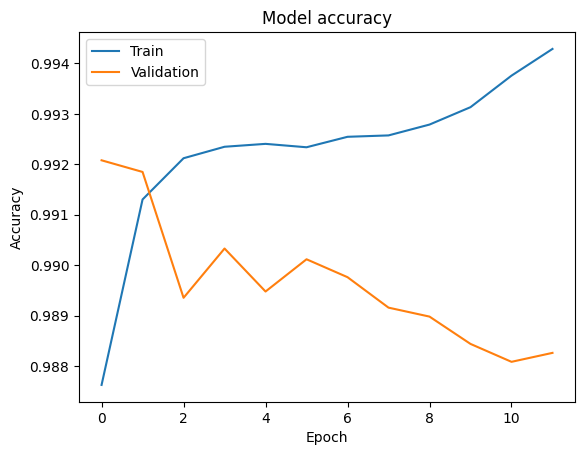

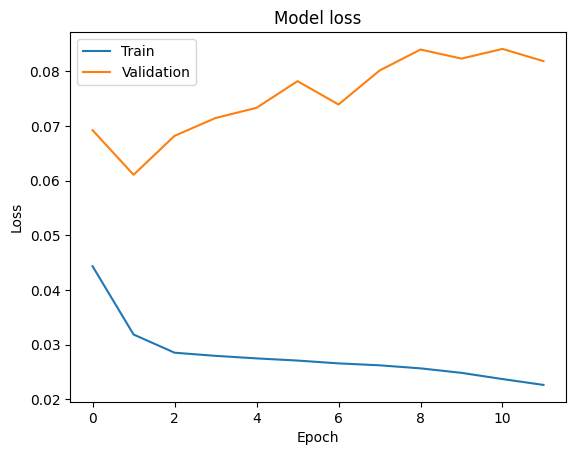

C:\Users\asus\AppData\Local\Temp\ipykernel_9936\1826519622.py:75: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=False.
  df1= pd.read_csv(r"D:\Datasets\Dataset_4L\Testing\CICDDoS2019_87F_TESTING_DATASET_FRONT_SEQUANTIAL_MULTI_Replace.csv")


(112611, 7)
Label
0    56306
1    56305
Name: count, dtype: int64
3520/3520 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9877 - loss: 0.0962
Test Loss: 0.06271234154701233
Test Accuracy: 0.9914928674697876
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Test_Time(Sec) : 1.261784315109253
Predictions (binary): [[0]
 [0]
 [0]
 ...
 [1]
 [1]
 [1]]
Manual Accuracy: 0.9914928381774427
Sensitivity : 0.996856407068644
Specificity : 0.9861293645437431
Precision : 0.98627633590469
Accuracy : 0.9914928381774427
F1_SCORE : 0.9915381489921742
Balance Accuracy : 0.9914928858061935


C:\Users\asus\AppData\Local\Temp\ipykernel_9936\1826519622.py:145: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=False.
  df3= pd.read_csv(r'D:\Datasets\Dataset_4L\Testing\CICDDoS2019_87F_TESTING_DATASET_RANDOM_1_MULTI_Replace.csv')


(112611, 7)
Label
0    56306
1    56305
Name: count, dtype: int64
3520/3520 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9881 - loss: 0.0942
Test Loss: 0.05914735049009323
Test Accuracy: 0.992407500743866
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Test_Time(Sec) : 1.1369109153747559
Predictions (binary): [[0]
 [0]
 [0]
 ...
 [1]
 [1]
 [1]]
Manual Accuracy: 0.992407491275275
Sensitivity : 0.9985969274487169
Specificity : 0.9862181650268177
Precision : 0.9863864425809621
Accuracy : 0.992407491275275
F1_SCORE : 0.9924541290476316
Balance Accuracy : 0.9924075462377673


C:\Users\asus\AppData\Local\Temp\ipykernel_9936\1826519622.py:178: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=False.
  df4= pd.read_csv(r'D:\Datasets\Dataset_4L\Testing\CICDDoS2019_87F_TESTING_DATASET_RANDOM_2_MULTI_Replace.csv')


(112611, 7)
Label
0    56306
1    56305
Name: count, dtype: int64
3520/3520 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9881 - loss: 0.0942
Test Loss: 0.0588400773704052
Test Accuracy: 0.9924874305725098
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Test_Time(Sec) : 1.120812177658081
Predictions (binary): [[0]
 [0]
 [0]
 ...
 [1]
 [1]
 [1]]
Manual Accuracy: 0.9924874124197458
Sensitivity : 0.9987567711570908
Specificity : 0.9862181650268177
Precision : 0.9863885916752907
Accuracy : 0.9924874124197458
F1_SCORE : 0.9925341522821137
Balance Accuracy : 0.9924874680919542


C:\Users\asus\AppData\Local\Temp\ipykernel_9936\1826519622.py:212: DtypeWarning: Columns (84) have mixed types. Specify dtype option on import or set low_memory=False.
  validation= pd.read_csv(r'D:\Datasets\Dataset_4L\CICDDoS2019_87F_VALIDATION_BACK_SEQUANTIAL_MULTI_CLASS_1L.csv')


(112612, 7)
Label
0    56425
1    56187
Name: count, dtype: int64
3520/3520 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9881 - loss: 0.0835
Test Loss: 0.052064333111047745
Test Accuracy: 0.9914751648902893
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Test_Time(Sec) : 1.140716552734375
Predictions (binary): [[0]
 [0]
 [0]
 ...
 [1]
 [1]
 [1]]
Manual Accuracy: 0.9914751536248357
Sensitivity : 0.994678484346913
Specificity : 0.9882853345148427
Precision : 0.988311022299245
Accuracy : 0.9914751536248357
F1_SCORE : 0.9914845302299178
Balance Accuracy : 0.9914819094308778


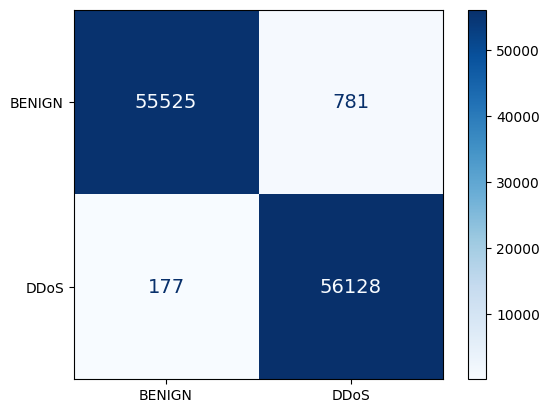

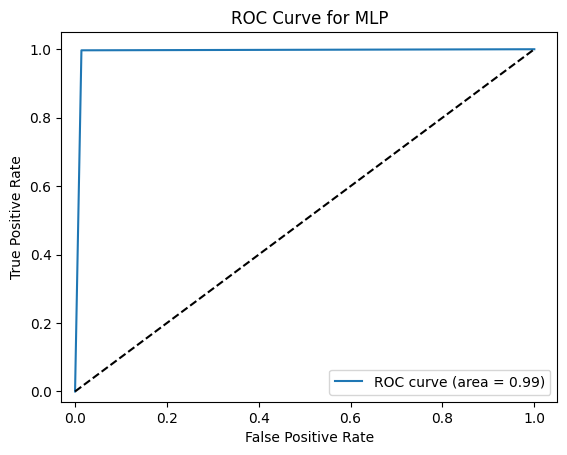

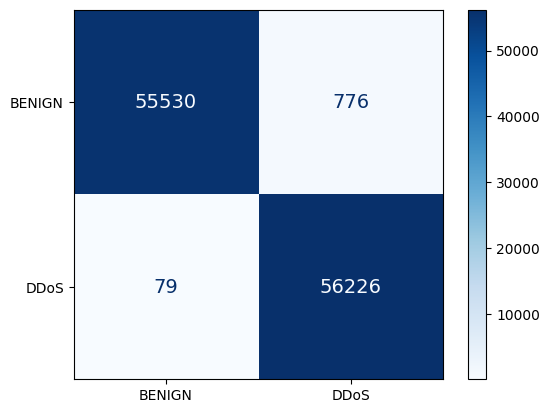

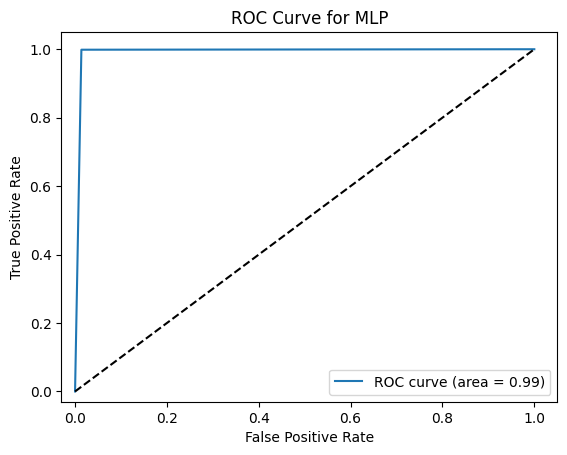

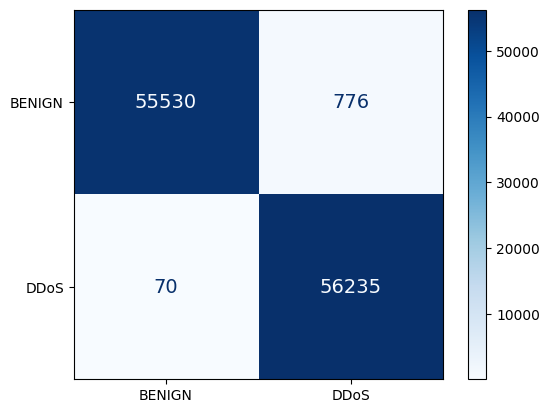

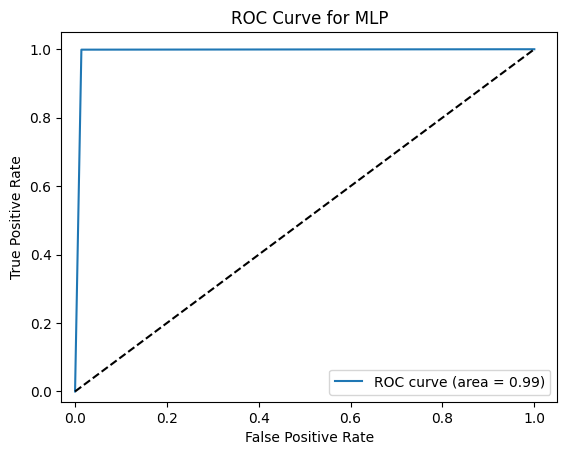

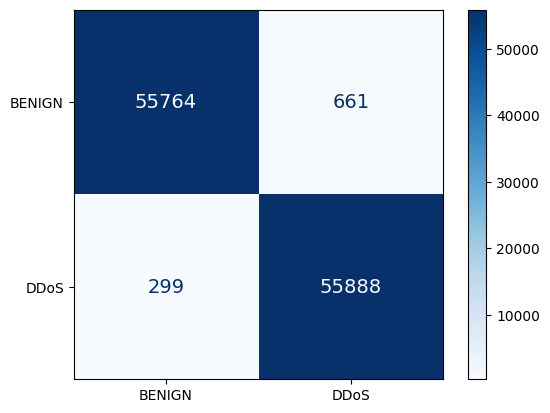

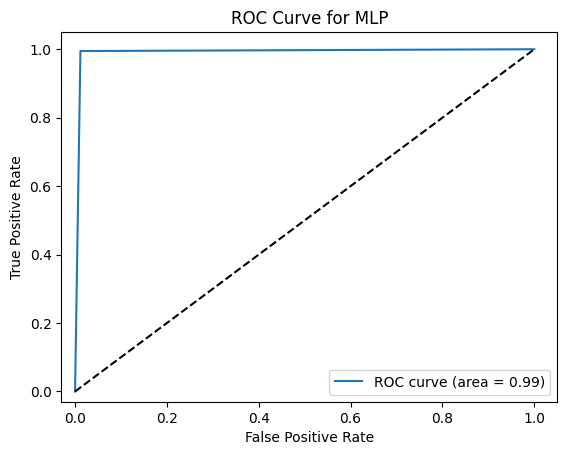

In [11]:

normalization_path = os.path.join(base_path, "Quantile_Normalization")
Path = create_directory(normalization_path)
#print(Min_Max_Normalization_Path)

current_dir_name = os.path.basename(Path)

X = df.iloc[:,:-1]  # Drop the label column to get features
y_train = df.iloc[:,-1:]
X_train=Quantile_Transform(X)

# Validation_set= pd.read_csv(r"D:\Datasets\Dataset_4L\CICDDoS2019_87F_VALIDATION_BACK_SEQUANTIAL_MULTI_CLASS_1L.csv")
Validation_set= pd.read_csv(r"D:\Datasets\Dataset_4L\Testing\CICDDoS2019_87F_TESTING_DATASET_BACK_SEQUANTIAL_MULTI_Replace.csv")
Validation_set=Validation_set[Features]
Validation_set['Label']=[0 if x == 'BENIGN' else 1 for x in Validation_set['Label']]
X_val=Validation_set.iloc[:,:-1]
X_val=Quantile_Transform(X_val)
y_val=Validation_set['Label']



#df= pd.read_csv(r'C:\Users\Student\RAGHU\CICDDoS2019_FROM_JULY_2024\4L_DATASET\4L_INBOUND_DATASET\Original\REPLACE_NEGATIVE\CICDDoS2019_87F_TRAIN_DATASET_FRONT_SEQUANTIAL_MULTI_CLASS_with_imputation_4L.csv')

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
before_memory = psutil.Process().memory_info().rss
start=time.time()
# Fit the model with early stopping callback
history = model.fit(X_train, y_train,
                    batch_size=batch_size,
                    epochs=50,
                    validation_data=(X_val, y_val),
                    callbacks=[early_stopping])
after_memory = psutil.Process().memory_info().rss
memory_used=after_memory-before_memory
end=time.time()
print("Memory_Used (MB):",memory_used/(1024*1024))
print("Train_Time(Sec) :", (end-start))

test_loss, test_accuracy = model.evaluate(X_val, y_val)
print(f'Validation Loss: {test_loss}')
print(f'Validation Accuracy: {test_accuracy}')
# Step 9: Evaluate the model on test data
model_filename = current_dir_name+"_"+"4L_MLP_model_WVC_15F_RANDOM_1_MIN_MAX_5_LAYERS_BATCH_1024.sav"
model_save_path = os.path.join(Path, model_filename)
pickle.dump(model, open(model_save_path,'wb'))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.savefig(os.path.join(Path, 'MLP_4L_15F_5_layers_validation_accuracy.png'))
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig(os.path.join(Path,'MLP_4L_15F_5_layers_validation_Loss.png'))
plt.show()





wb = xw.Book()
# Assuming you have trained the model and X_train, y_train are your training data
# X_test and y_test are your test data
# Also assuming normalization was applied to X_train, so apply the same transformation to X_test

df1= pd.read_csv(r"D:\Datasets\Dataset_4L\Testing\CICDDoS2019_87F_TESTING_DATASET_FRONT_SEQUANTIAL_MULTI_Replace.csv")
df1=df1[Features]
df1['Label']=[0 if x == 'BENIGN' else 1 for x in df1['Label']]
print(df1.shape)
print(df1['Label'].value_counts())


X_test = df1.iloc[:,:-1]
y_test=df1['Label']
# Preprocess X_test if needed (e.g., normalization, scaling)
X_test = Quantile_Transform(X_test)  # Make sure the normalization is consistent with the training data

# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# Make predictions on test data
start=time.time()
y_pred = model.predict(X_test, batch_size=batch_size)
end=time.time()
print("Test_Time(Sec) :", (end-start))
# Convert predictions to binary (0 or 1) using a threshold of 0.5
y_pred_binary = (y_pred > 0.5).astype(int)

# Print first 10 predictions
print(f"Predictions (binary): {y_pred_binary[:112611]}")

# Calculate accuracy manually (optional)
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Manual Accuracy: {accuracy}")
Evaluation_Metrics(y_test, y_pred_binary,"D1_Dataset",Path)


# df2= pd.read_csv(r'D:\Datasets\Dataset_4L\Testing\CICDDoS2019_87F_TESTING_DATASET_BACK_SEQUANTIAL_MULTI_Replace.csv')
# df2=df2[Features]
# df2['Label']=[0 if x == 'BENIGN' else 1 for x in df2['Label']]
# print(df2.shape)
# print(df2['Label'].value_counts())

# X_test = df2.iloc[:,:-1]
# y_test=df2['Label']
# # Preprocess X_test if needed (e.g., normalization, scaling)
# X_test = Quantile_Transform(X_test)  # Make sure the normalization is consistent with the training data

# # Evaluate the model on test data
# # test_loss, test_accuracy = model.evaluate(X_test, y_test)
# # print(f"Test Loss: {test_loss}")
# # print(f"Test Accuracy: {test_accuracy}")

# # Make predictions on test data
# start=time.time()
# y_pred = model.predict(X_test, batch_size=batch_size)
# end=time.time()
# print("Test_Time(Sec) :", (end-start))
# # Convert predictions to binary (0 or 1) using a threshold of 0.5
# y_pred_binary = (y_pred > 0.5).astype(int)

# # Print first 10 predictions
# print(f"Predictions (binary): {y_pred_binary[:112611]}")

# # Calculate accuracy manually (optional)
# accuracy = accuracy_score(y_test, y_pred_binary)
# print(f"Manual Accuracy: {accuracy}")
# #wb = xw.Book()
# Evaluation_Metrics(y_test, y_pred_binary,"D2_Dataset",Path)




df3= pd.read_csv(r'D:\Datasets\Dataset_4L\Testing\CICDDoS2019_87F_TESTING_DATASET_RANDOM_1_MULTI_Replace.csv')
df3=df3[Features]
df3['Label']=[0 if x == 'BENIGN' else 1 for x in df3['Label']]
print(df3.shape)
print(df3['Label'].value_counts())
X_test = df3.iloc[:,:-1]
y_test=df3['Label']
# Preprocess X_test if needed (e.g., normalization, scaling)
X_test = Quantile_Transform(X_test)  # Make sure the normalization is consistent with the training data

# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# Make predictions on test data
start=time.time()
y_pred = model.predict(X_test, batch_size=batch_size)
end=time.time()
print("Test_Time(Sec) :", (end-start))
# Convert predictions to binary (0 or 1) using a threshold of 0.5
y_pred_binary = (y_pred > 0.5).astype(int)

# Print first 10 predictions
print(f"Predictions (binary): {y_pred_binary[:112611]}")

# Calculate accuracy manually (optional)
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Manual Accuracy: {accuracy}")
Evaluation_Metrics(y_test, y_pred_binary,"D3_Dataset",Path)



df4= pd.read_csv(r'D:\Datasets\Dataset_4L\Testing\CICDDoS2019_87F_TESTING_DATASET_RANDOM_2_MULTI_Replace.csv')
df4=df4[Features]
df4['Label']=[0 if x == 'BENIGN' else 1 for x in df4['Label']]
print(df4.shape)
print(df4['Label'].value_counts())
X_test = df4.iloc[:,:-1]
y_test=df4['Label']
# Preprocess X_test if needed (e.g., normalization, scaling)
X_test = Quantile_Transform(X_test)  # Make sure the normalization is consistent with the training data

# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# Make predictions on test data
start=time.time()
y_pred = model.predict(X_test, batch_size=batch_size)
end=time.time()
print("Test_Time(Sec) :", (end-start))
# Convert predictions to binary (0 or 1) using a threshold of 0.5
y_pred_binary = (y_pred > 0.5).astype(int)

# Print first 10 predictions
print(f"Predictions (binary): {y_pred_binary[:112611]}")

# Calculate accuracy manually (optional)
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Manual Accuracy: {accuracy}")
Evaluation_Metrics(y_test, y_pred_binary,"D4_Dataset",Path)




validation= pd.read_csv(r'D:\Datasets\Dataset_4L\CICDDoS2019_87F_VALIDATION_BACK_SEQUANTIAL_MULTI_CLASS_1L.csv')
validation=validation[Features]
validation['Label']=[0 if x == 'BENIGN' else 1 for x in validation['Label']]
print(validation.shape)
print(validation['Label'].value_counts())
X_test = validation.iloc[:,:-1]
y_test=validation['Label']
# Preprocess X_test if needed (e.g., normalization, scaling)
X_test = Quantile_Transform(X_test)  # Make sure the normalization is consistent with the training data

# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# Make predictions on test data
start=time.time()
y_pred = model.predict(X_test, batch_size=batch_size)
end=time.time()
print("Test_Time(Sec) :", (end-start))
# Convert predictions to binary (0 or 1) using a threshold of 0.5
y_pred_binary = (y_pred > 0.5).astype(int)

# Print first 10 predictions
print(f"Predictions (binary): {y_pred_binary[:112611]}")

# Calculate accuracy manually (optional)
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Manual Accuracy: {accuracy}")
Evaluation_Metrics(y_test, y_pred_binary,"Validation_Dataset", Path)



excel_filename = "Quantile_WVC_15F_RANDOM_1_Results.xlsx"
excel_save_path = os.path.join(Path, excel_filename)
wb.save(excel_save_path)
wb.close()

Standardization

In [12]:

# normalization_path = os.path.join(base_path, "Standardization_Normalization")
# Path = create_directory(normalization_path)
# #print(Min_Max_Normalization_Path)

# current_dir_name = os.path.basename(Path)

# X = df.iloc[:,:-1]  # Drop the label column to get features
# y_train = df.iloc[:,-1:]
# X_train=Standardization(X)

# # Validation_set= pd.read_csv(r"D:\Datasets\Dataset_4L\CICDDoS2019_87F_VALIDATION_BACK_SEQUANTIAL_MULTI_CLASS_1L.csv")
# Validation_set= pd.read_csv(r"D:\Datasets\Dataset_4L\Testing\CICDDoS2019_87F_TESTING_DATASET_BACK_SEQUANTIAL_MULTI_Replace.csv")
# Validation_set=Validation_set[Features]
# Validation_set['Label']=[0 if x == 'BENIGN' else 1 for x in Validation_set['Label']]
# X_val=Validation_set.iloc[:,:-1]
# X_val=Standardization(X_val)
# y_val=Validation_set['Label']



# #df= pd.read_csv(r'C:\Users\Student\RAGHU\CICDDoS2019_FROM_JULY_2024\4L_DATASET\4L_INBOUND_DATASET\Original\REPLACE_NEGATIVE\CICDDoS2019_87F_TRAIN_DATASET_FRONT_SEQUANTIAL_MULTI_CLASS_with_imputation_4L.csv')

# early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
# before_memory = psutil.Process().memory_info().rss
# start=time.time()
# # Fit the model with early stopping callback
# history = model.fit(X_train, y_train,
#                     batch_size=batch_size,
#                     epochs=50,
#                     validation_data=(X_val, y_val),
#                     callbacks=[early_stopping])
# after_memory = psutil.Process().memory_info().rss
# memory_used=after_memory-before_memory
# end=time.time()
# print("Memory_Used (MB):",memory_used/(1024*1024))
# print("Train_Time(Sec) :", (end-start))

# test_loss, test_accuracy = model.evaluate(X_val, y_val)
# print(f'Validation Loss: {test_loss}')
# print(f'Validation Accuracy: {test_accuracy}')
# # Step 9: Evaluate the model on test data
# model_filename = "4L_MLP_model_WVC_15F_RANDOM_1_MIN_MAX_5_LAYERS_BATCH_1024.sav"
# model_save_path = os.path.join(Path, model_filename)
# pickle.dump(model, open(model_save_path,'wb'))

# plt.plot(history.history['accuracy'])
# plt.plot(history.history['val_accuracy'])
# plt.title('Model accuracy')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy')
# plt.legend(['Train', 'Validation'], loc='upper left')

# plt.savefig(os.path.join(Path, 'MLP_4L_15F_5_layers_validation_accuracy.png'))
# plt.show()

# # Plot training & validation loss values
# plt.plot(history.history['loss'])
# plt.plot(history.history['val_loss'])
# plt.title('Model loss')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend(['Train', 'Validation'], loc='upper left')
# plt.savefig(os.path.join(Path,'MLP_4L_15F_5_layers_validation_Loss.png'))
# plt.show()





# wb = xw.Book()
# # Assuming you have trained the model and X_train, y_train are your training data
# # X_test and y_test are your test data
# # Also assuming normalization was applied to X_train, so apply the same transformation to X_test

# df1= pd.read_csv(r"D:\Datasets\Dataset_4L\Testing\CICDDoS2019_87F_TESTING_DATASET_FRONT_SEQUANTIAL_MULTI_Replace.csv")
# df1=df1[Features]
# df1['Label']=[0 if x == 'BENIGN' else 1 for x in df1['Label']]
# print(df1.shape)
# print(df1['Label'].value_counts())


# X_test = df1.iloc[:,:-1]
# y_test=df1['Label']
# # Preprocess X_test if needed (e.g., normalization, scaling)
# X_test = Standardization(X_test)  # Make sure the normalization is consistent with the training data

# # Evaluate the model on test data
# test_loss, test_accuracy = model.evaluate(X_test, y_test)
# print(f"Test Loss: {test_loss}")
# print(f"Test Accuracy: {test_accuracy}")

# # Make predictions on test data
# start=time.time()
# y_pred = model.predict(X_test, batch_size=batch_size)
# end=time.time()
# print("Test_Time(Sec) :", (end-start))
# # Convert predictions to binary (0 or 1) using a threshold of 0.5
# y_pred_binary = (y_pred > 0.5).astype(int)

# # Print first 10 predictions
# print(f"Predictions (binary): {y_pred_binary[:112611]}")

# # Calculate accuracy manually (optional)
# accuracy = accuracy_score(y_test, y_pred_binary)
# print(f"Manual Accuracy: {accuracy}")
# Evaluation_Metrics(y_test, y_pred_binary,"D1_Dataset",Path)


# # df2= pd.read_csv(r'D:\Datasets\Dataset_4L\Testing\CICDDoS2019_87F_TESTING_DATASET_BACK_SEQUANTIAL_MULTI_Replace.csv')
# # df2=df2[Features]
# # df2['Label']=[0 if x == 'BENIGN' else 1 for x in df2['Label']]
# # print(df2.shape)
# # print(df2['Label'].value_counts())

# # X_test = df2.iloc[:,:-1]
# # y_test=df2['Label']
# # # Preprocess X_test if needed (e.g., normalization, scaling)
# # X_test = Standardization(X_test)  # Make sure the normalization is consistent with the training data

# # # Evaluate the model on test data
# # # test_loss, test_accuracy = model.evaluate(X_test, y_test)
# # # print(f"Test Loss: {test_loss}")
# # # print(f"Test Accuracy: {test_accuracy}")

# # # Make predictions on test data
# # start=time.time()
# # y_pred = model.predict(X_test, batch_size=batch_size)
# # end=time.time()
# # print("Test_Time(Sec) :", (end-start))
# # # Convert predictions to binary (0 or 1) using a threshold of 0.5
# # y_pred_binary = (y_pred > 0.5).astype(int)

# # # Print first 10 predictions
# # print(f"Predictions (binary): {y_pred_binary[:112611]}")

# # # Calculate accuracy manually (optional)
# # accuracy = accuracy_score(y_test, y_pred_binary)
# # print(f"Manual Accuracy: {accuracy}")
# # #wb = xw.Book()
# # Evaluation_Metrics(y_test, y_pred_binary,"D2_Dataset",Path)




# df3= pd.read_csv(r'D:\Datasets\Dataset_4L\Testing\CICDDoS2019_87F_TESTING_DATASET_RANDOM_1_MULTI_Replace.csv')
# df3=df3[Features]
# df3['Label']=[0 if x == 'BENIGN' else 1 for x in df3['Label']]
# print(df3.shape)
# print(df3['Label'].value_counts())
# X_test = df3.iloc[:,:-1]
# y_test=df3['Label']
# # Preprocess X_test if needed (e.g., normalization, scaling)
# X_test = Standardization(X_test)  # Make sure the normalization is consistent with the training data

# # Evaluate the model on test data
# test_loss, test_accuracy = model.evaluate(X_test, y_test)
# print(f"Test Loss: {test_loss}")
# print(f"Test Accuracy: {test_accuracy}")

# # Make predictions on test data
# start=time.time()
# y_pred = model.predict(X_test, batch_size=batch_size)
# end=time.time()
# print("Test_Time(Sec) :", (end-start))
# # Convert predictions to binary (0 or 1) using a threshold of 0.5
# y_pred_binary = (y_pred > 0.5).astype(int)

# # Print first 10 predictions
# print(f"Predictions (binary): {y_pred_binary[:112611]}")

# # Calculate accuracy manually (optional)
# accuracy = accuracy_score(y_test, y_pred_binary)
# print(f"Manual Accuracy: {accuracy}")
# Evaluation_Metrics(y_test, y_pred_binary,"D3_Dataset",Path)



# df4= pd.read_csv(r'D:\Datasets\Dataset_4L\Testing\CICDDoS2019_87F_TESTING_DATASET_RANDOM_2_MULTI_Replace.csv')
# df4=df4[Features]
# df4['Label']=[0 if x == 'BENIGN' else 1 for x in df4['Label']]
# print(df4.shape)
# print(df4['Label'].value_counts())
# X_test = df4.iloc[:,:-1]
# y_test=df4['Label']
# # Preprocess X_test if needed (e.g., normalization, scaling)
# X_test = Standardization(X_test)  # Make sure the normalization is consistent with the training data

# # Evaluate the model on test data
# test_loss, test_accuracy = model.evaluate(X_test, y_test)
# print(f"Test Loss: {test_loss}")
# print(f"Test Accuracy: {test_accuracy}")

# # Make predictions on test data
# start=time.time()
# y_pred = model.predict(X_test, batch_size=batch_size)
# end=time.time()
# print("Test_Time(Sec) :", (end-start))
# # Convert predictions to binary (0 or 1) using a threshold of 0.5
# y_pred_binary = (y_pred > 0.5).astype(int)

# # Print first 10 predictions
# print(f"Predictions (binary): {y_pred_binary[:112611]}")

# # Calculate accuracy manually (optional)
# accuracy = accuracy_score(y_test, y_pred_binary)
# print(f"Manual Accuracy: {accuracy}")
# Evaluation_Metrics(y_test, y_pred_binary,"D4_Dataset",Path)




# validation= pd.read_csv(r'D:\Datasets\Dataset_4L\CICDDoS2019_87F_VALIDATION_BACK_SEQUANTIAL_MULTI_CLASS_1L.csv')
# validation=validation[Features]
# validation['Label']=[0 if x == 'BENIGN' else 1 for x in validation['Label']]
# print(validation.shape)
# print(validation['Label'].value_counts())
# X_test = validation.iloc[:,:-1]
# y_test=validation['Label']
# # Preprocess X_test if needed (e.g., normalization, scaling)
# X_test = Standardization(X_test)  # Make sure the normalization is consistent with the training data

# # Evaluate the model on test data
# test_loss, test_accuracy = model.evaluate(X_test, y_test)
# print(f"Test Loss: {test_loss}")
# print(f"Test Accuracy: {test_accuracy}")

# # Make predictions on test data
# start=time.time()
# y_pred = model.predict(X_test, batch_size=batch_size)
# end=time.time()
# print("Test_Time(Sec) :", (end-start))
# # Convert predictions to binary (0 or 1) using a threshold of 0.5
# y_pred_binary = (y_pred > 0.5).astype(int)

# # Print first 10 predictions
# print(f"Predictions (binary): {y_pred_binary[:112611]}")

# # Calculate accuracy manually (optional)
# accuracy = accuracy_score(y_test, y_pred_binary)
# print(f"Manual Accuracy: {accuracy}")
# Evaluation_Metrics(y_test, y_pred_binary,"Validation_Dataset", Path)



# excel_filename = "Standardization_WVC_15F_RANDOM_1_Results.xlsx"
# excel_save_path = os.path.join(Path, excel_filename)
# wb.save(excel_save_path)
# wb.close()